# Example 2: Predicting Used Car Price

The file `toyota.csv` (from the course website) contains the data of used cars (Toyota Corolla) on sale. It has 1,436 records of 15 variables

* Price
* Age (age in months)
* KM (kilometer)
* Fuel_type (Petrol, Diesel, CNG)
* HP (horsepower)
* CC (cylinder volume)
* Doors (number of doors)
* Tax (quarterly tax)
* Weight (weight in kg)
* 6 binary variables (Yes=1, No=0): Met_Color, Automatic, CD_Player, Airbag_2, Airco & Tow_Bar 

The goal is to predict the price of a used Toyota Corolla based on its specifications (i.e., the 14 features). Note that Fuel_Type is a categorical variable (Petro, Diesel, CNG) which is required to transformed to binary variables. 

---

* Part 1: Data Preparation & Exploration
* Part 2: Model Estimation
* Part 3: Feature Selection
* Part 4: Prediction

---

# Part 1 Data Preparation and Exploration

In [109]:
# load libraries
# standard libraries & graph setting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
# librabries for regressions
# sklearn
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score as R2
from sklearn.metrics import mean_squared_error as MSE
from sklearn.feature_selection import RFE

# statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [110]:
import os

# Get current working directory
cwd = os.getcwd()

print("Current Working Directory:", cwd)
# Define the new path you want to change to
new_path = "C:/Users/vansh/Downloads" 

# Change the working directory
os.chdir(new_path)


Current Working Directory: C:\Users\vansh\Downloads


In [111]:
#load data 
tc=pd.read_csv("toyota-1.csv")
tc.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age        1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Met_Color  1436 non-null   int64 
 6   Automatic  1436 non-null   int64 
 7   CC         1436 non-null   int64 
 8   Doors      1436 non-null   int64 
 9   Tax        1436 non-null   int64 
 10  Weight     1436 non-null   int64 
 11  CD_Player  1436 non-null   int64 
 12  Airbag_2   1436 non-null   int64 
 13  Airco      1436 non-null   int64 
 14  Tow_Bar    1436 non-null   int64 
dtypes: int64(14), object(1)
memory usage: 168.4+ KB


In [112]:
tc.describe(include=["O"])

,Fuel_Type
count,1436
unique,3
top,Petrol
freq,1264


In [113]:
tc.Fuel_Type.value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [114]:
# Get dummies to make the Fuel type into Binary codes
Dtc=pd.get_dummies(tc,drop_first=False).astype(int)
Dtc.head()


,Price,Age,KM,HP,Met_Color,Automatic,CC,Doors,Tax,Weight,CD_Player,Airbag_2,Airco,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,1,0,2000,3,210,1165,0,1,0,0,0,1,0
1,13750,23,72937,90,1,0,2000,3,210,1165,1,1,1,0,0,1,0
2,13950,24,41711,90,1,0,2000,3,210,1165,0,1,0,0,0,1,0
3,14950,26,48000,90,0,0,2000,3,210,1165,0,1,0,0,0,1,0
4,13750,30,38500,90,0,0,2000,3,210,1170,0,1,1,0,0,1,0


<Axes: ylabel='Frequency'>

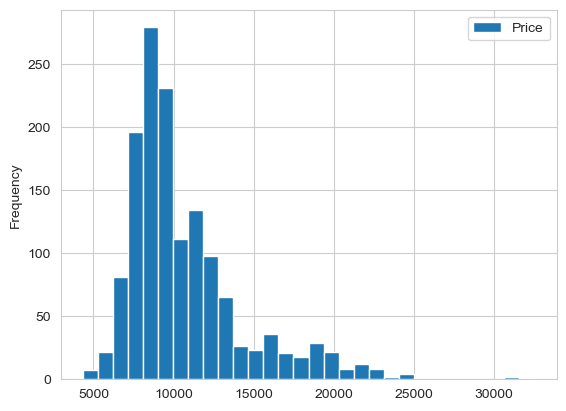

In [115]:
# Lets see the price Distribution 
Dtc.plot(y="Price",kind="hist",bins=30)

<Axes: >

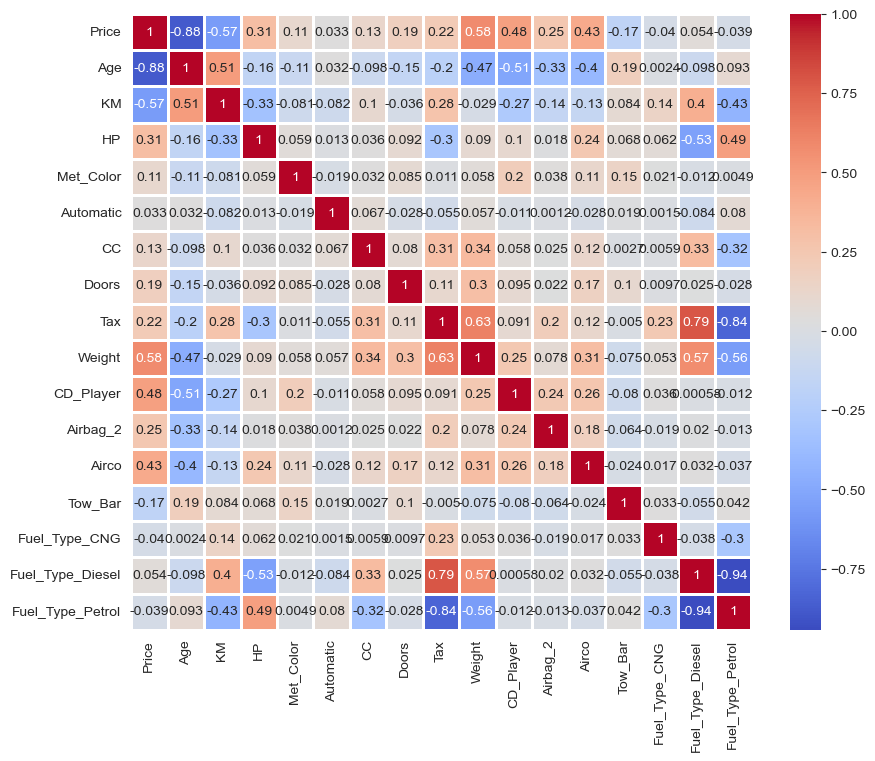

In [116]:
# Generate a heatmap for pairwise correlation 
plt.figure(figsize=(10,8))
sns.heatmap(Dtc.corr(),linewidths=1,annot=True,cmap="coolwarm")


**Notes**

* Correlation between each features & target (price)
    * strogest: Age & KM (negative) & Weight, CD_Player, Airco, HP (positive)
    * weakest: Automatic
* Correlation among features: many of them are a bit collinear -- e.g., Age & KM, Tax & Weight

# Part 2 Model Estimation

In [129]:
# Define the Independent and Dependent Variable 
X,y= Dtc.drop("Price",axis=1), Dtc["Price"]

In [137]:
# Set the Regression Model 
LR = LinearRegression()
LR.fit(X,y)
# Print Intercept and slope 
print("Intercept = ", LR.intercept_)
print("coef=", LR.coef_)


Intercept =  -4855.589897006421
coef= [-1.18782902e+02 -1.73018724e-02  2.29427870e+01  1.93238617e+01
  3.17673149e+02 -7.77760860e-02 -6.70277943e+01  1.52205517e+01
  1.76689807e+01  3.11659830e+02 -4.02617845e+02  3.42198876e+02
 -2.70495907e+02 -1.14643018e+03 -3.94227499e+02  1.54065768e+03]


In [145]:
# Model Estimation 
print("Model Estimation Coef : \n")
for i in range(X.shape[1]):
    print(X.columns[i],"=", LR.coef_[i].round(3))

Model Estimation Coef : 

Age = -118.783
KM = -0.017
HP = 22.943
Met_Color = 19.324
Automatic = 317.673
CC = -0.078
Doors = -67.028
Tax = 15.221
Weight = 17.669
CD_Player = 311.66
Airbag_2 = -402.618
Airco = 342.199
Tow_Bar = -270.496
Fuel_Type_CNG = -1146.43
Fuel_Type_Diesel = -394.227
Fuel_Type_Petrol = 1540.658


In [147]:
# Put in data Frame
pd.DataFrame(LR.coef_,index=X.columns).round(3).T

,Age,KM,HP,Met_Color,Automatic,CC,Doors,Tax,Weight,CD_Player,Airbag_2,Airco,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,-118.783,-0.017,22.943,19.324,317.673,-0.078,-67.028,15.221,17.669,311.66,-402.618,342.199,-270.496,-1146.43,-394.227,1540.658


In [151]:
# Prediction
yp = LR.predict(X)
Dtc["Price_P"]=yp
yp

array([16310.82973183, 16515.68754591, 16283.31420683, ...,
        8209.57608165,  8752.03087756,  9694.11075206])

In [153]:
def adj_r2(y,yp,X):
    return(1 - (1-R2(y, yp))*(len(y)-1)/(len(y)-X.shape[1]-1))

In [157]:
# R-squared
print("R-squared =", R2(y, yp).round(3))
# MSE (mean squared error)
print("MSE =", MSE(y, yp).round(3))
# Adj R-squared
print('Adj. R-squared', adj_r2(y, yp, X).round(3))

R-squared = 0.874
MSE = 1654289.736
Adj. R-squared 0.873


# ---------------- Model Evaluation Summary ----------------
##### R-squared: Measures how well the model explains the variance in the target variable (Price).
###### - Value: 0.874 → The model explains 87.4% of the variation in car prices.
###### - Higher is better (maximum = 1.0).

###### MSE (Mean Squared Error): Measures the average squared difference between predicted and actual values.
###### - Value: 1,654,289.736 → On average, predictions are off by this amount squared.
###### - Lower is better; this value is acceptable if car prices are in the thousands.

###### Adjusted R-squared: Similar to R-squared but penalizes for unnecessary features.
###### - Value: 0.873 → Very close to R², indicating most features are useful and the model is not overfitting.

###### Conclusion: The model performs well, explains most of the variance in price, 
###### and includes relevant features without overfitting.
# -----------------------------------------------------------


# Part 3 
###### lasso
###### Recursive Feature Elimination (RFE)

In [174]:
# Z-std Scaling (RT2)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std=pd.DataFrame(X_std)
X_std.agg(['mean',"std"]).round(3)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
mean,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [176]:
# We Apply Standard Scalling to bring all the values to the same scale, which is better for Machine Learning 
# Thing of an example where we have a dataset for Age, Height, Occupation, and Salary. The Salary section would have a higher value due to its scale. 
# So its better to scale the values so the model doesnt give importance to higher values.


In [182]:
# What is Lasso 
# Lasso Stands for  Least Absolute Shrinkage and Selection Operator.
# Lasso does two things 
# 1 Fits linear model 
# 2 Adds a penalty on the absolute values 
# Shrinks less important coefficients
# Set unimportant coef to 0.

In [184]:
# LASSO
lasso = Lasso(alpha=1)
lasso.fit(X_std,y)
pd.DataFrame(lasso.coef_,index=X.columns).T

,Age,KM,HP,Met_Color,Automatic,CC,Doors,Tax,Weight,CD_Player,Airbag_2,Airco,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,-2207.974708,-649.499048,344.183001,7.875737,71.96357,-31.684589,-61.862434,617.899872,928.545495,128.321093,-177.240138,170.304917,-119.935515,-189.885853,-312.682485,292.726416


In [194]:
# Changing the Alpha would stricts the regularisation 
lasso = Lasso(alpha=50)
lasso.fit(X_std,y)
pd.DataFrame(lasso.coef_,index=X.columns).T

,Age,KM,HP,Met_Color,Automatic,CC,Doors,Tax,Weight,CD_Player,Airbag_2,Airco,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,-2176.715561,-681.816504,371.602471,0.0,28.578789,-0.0,-0.0,237.250318,891.70703,94.673065,-31.699031,132.864843,-63.565874,-53.560506,-0.0,222.973042


In [196]:
# Changing the Alpha would stricts the regularisation 
lasso = Lasso(alpha=500)
lasso.fit(X_std,y)
pd.DataFrame(lasso.coef_,index=X.columns).T

,Age,KM,HP,Met_Color,Automatic,CC,Doors,Tax,Weight,CD_Player,Airbag_2,Airco,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,-2198.104989,-400.976098,114.59942,0.0,0.0,0.0,0.0,0.0,551.846079,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0


In [198]:
# Recursive Feature Selection 
# Its a feature selection techique that helps us find the most important features for machine learning. 
# RFE ranks the features by importance, eliminates the least important feature. 

In [208]:
# import RFE
from sklearn.feature_selection import RFE
# fit RFE based on LR
# let's select the top 10 features
LR = LinearRegression()
rfe = RFE(LR, n_features_to_select=12, step=1).fit(X_std,y)

# ranking
pd.DataFrame(rfe.ranking_, index = X.columns).T

,Age,KM,HP,Met_Color,Automatic,CC,Doors,Tax,Weight,CD_Player,Airbag_2,Airco,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,1,1,1,5,2,4,3,1,1,1,1,1,1,1,1,1


In [210]:
# Therefore features with Rank 1 are selected


In [212]:
# Backward Selection 
# Backward Selection is a stepwise feature elemination method 
# Where we start with all the features, and start to eliminate the least significant ones ( p value <0.05)

In [214]:
XX=sm.add_constant(X)
results=sm.OLS(y,XX).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     657.6
Date:                Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                        20:17:56   Log-Likelihood:                -12319.
No. Observations:                1436   AIC:                         2.467e+04
Df Residuals:                    1420   BIC:                         2.475e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3641.6924    911.774  

In [216]:
XX1=XX.drop("Met_Color",axis=1)
results1=sm.OLS(y,XX1).fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     705.0
Date:                Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                        20:20:24   Log-Likelihood:                -12319.
No. Observations:                1436   AIC:                         2.467e+04
Df Residuals:                    1421   BIC:                         2.475e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3630.1589    910.352  

In [238]:
XX2=XX1.drop("CC",axis=1)
results1=sm.OLS(y,XX2).fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     759.3
Date:                Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                        20:36:44   Log-Likelihood:                -12319.
No. Observations:                1436   AIC:                         2.467e+04
Df Residuals:                    1422   BIC:                         2.474e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3660.6954    909.596  

In [249]:
XX3=XX2.drop(["Doors","Fuel_Type_Petrol"],axis=1)
results3=sm.OLS(y,XX3).fit()
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     821.2
Date:                Sun, 20 Jul 2025   Prob (F-statistic):               0.00
Time:                        20:37:55   Log-Likelihood:                -12320.
No. Observations:                1436   AIC:                         2.467e+04
Df Residuals:                    1423   BIC:                         2.474e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2941.2118   1144.901  

In [281]:
# Prediction
LR =LinearRegression()
LR.fit(X,y)
Dtc["Price_p"] = LR.predict(X)

In [283]:
X3 = X.drop(["Met_Color","CC","Doors","Fuel_Type_Petrol"],axis=1)
LR.fit(X3,y)
Dtc["Price_p1"]=LR.predict(X3)

Text(0, 0.5, 'Predicted Sales')

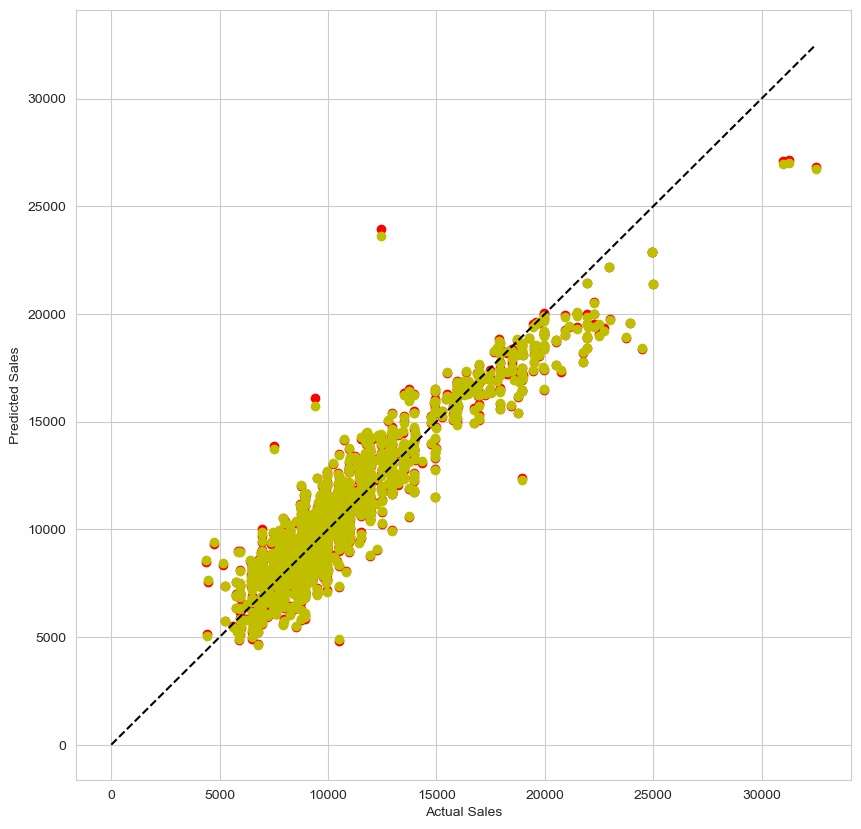

In [285]:
# Plot two Predictions against Actual Values
plt.figure(figsize=(10,10))
max = int(Dtc["Price"].max())+1
h=plt.plot(range(0,max,1),c="black",ls="--")
#Scatter plot 
plt.scatter(Dtc.Price,Dtc.Price_p,c="r")
plt.scatter(Dtc.Price,Dtc.Price_p1,c="y")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

In [291]:
# Adj R-squared (X)
print('Adj. R-squared', adj_r2(y, Dtc['Price_p'] , X).round(5))
# Adj R-squared (X3)
print('Adj. R-squared', adj_r2(y, Dtc['Price_p1'], X3).round(5))

Adj. R-squared 0.87274
Adj. R-squared 0.87276


### The simplified model (X3) has an Adjusted R-squared of 0.87276, which is very slightly higher than the full model (X) at 0.87274.

- This indicates that removing features (e.g., Met_Color, CC, Doors, etc.) did not reduce prediction accuracy.

- The full model uses more features but does not offer a significant gain in performance.

- Therefore, X3 is the better choice as it is:

- Parsimonious (simpler and easier to interpret)

- Efficient (less risk of overfitting)

- Nearly identical in predictive power